
# Score-Based Generative Models (RLD course)

This exercise notebook introduces score-based generative models from a Langevin
dynamics perspective, contrasting with the stochastic/denoising interpretation
of diffusion models.

The lab is structured in three parts:
- **Part 1**: Score-based fundamentals with 2D examples (Main session)
- **Part 2**: Score-based models for images and connection to diffusion (Main session)
- **Part 3**: Advanced sampling methods - SDE/ODE formulation (Optional, home learning)

A good overview can be found in [Yang Song's blog](https://yang-song.net/blog/2021/score/)
and the paper "Score-Based Generative Modeling through Stochastic Differential Equations".

## Required Packages

Before starting, please ensure you have the following packages installed:

**Core packages:**
- `torch` (>=1.12) - PyTorch for deep learning
- `torchvision` - Vision utilities and datasets
- `matplotlib` - Plotting and visualization
- `numpy` - Numerical computing
- `tqdm` - Progress bars

**Optional (for Part 3):**
- `scipy` - For ODE solving in Part 3 (optional advanced section)

**Installation commands:**
- **Conda:** `conda install pytorch torchvision matplotlib numpy tqdm scipy -c pytorch`
- **Pip:** `pip install torch torchvision matplotlib numpy tqdm scipy`

In [13]:
# For Google Colab users: Run this cell to install required packages
# !pip install torch torchvision matplotlib numpy tqdm scipy

In [14]:

# Import the necessary modules
from functools import partial
import math
import os

# Fix OpenMP library conflict on macOS (common issue with PyTorch)
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

# Use regular tqdm instead of autonotebook to avoid potential issues
try:
    from tqdm import tqdm
except ImportError:
    # Fallback if tqdm is not installed
    tqdm = lambda x, **kwargs: x

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

from torchvision import datasets, transforms
from torchvision.utils import make_grid

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

# For Part 3 (optional)
try:
    from scipy.integrate import odeint  # type: ignore
except ImportError:
    odeint = None  # type: ignore

# Device selection: prefer MPS (Apple Silicon) > CUDA > CPU
# Note: MPS can be unstable in some environments, use CPU if issues occur
try:
    if torch.backends.mps.is_available():
        device = torch.device("mps")
    elif torch.cuda.is_available():
        device = torch.device("cuda")
    else:
        device = torch.device("cpu")
except Exception as e:
    # Fallback to CPU if device selection fails
    print(f"Warning: Device selection failed ({e}), using CPU")
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cuda


In [15]:
# Main experimental settings
num_noise_levels = 10  # Number of noise levels for annealed Langevin
epochs = 5  # Training epochs for Part 2

In [16]:

if os.environ.get("TESTING_MODE", "off") == "ON":
    num_noise_levels = 3
    epochs = 1
    plt.show = lambda *args, **kwargs: None


# Part 1: Score-Based Fundamentals

In this part, we'll build intuition about score-based generative models using
simple 2D examples before moving to images.


## 1.1 Understanding the Score Function

The **score function** is the gradient of the log-probability density:
$$s_\theta(x) = \nabla_x \log p_\theta(x)$$

Why learn gradients instead of probabilities?
- We don't need the normalization constant (it disappears in the gradient)
- Gradients point toward higher probability regions
- We can sample by following gradients (Langevin dynamics)

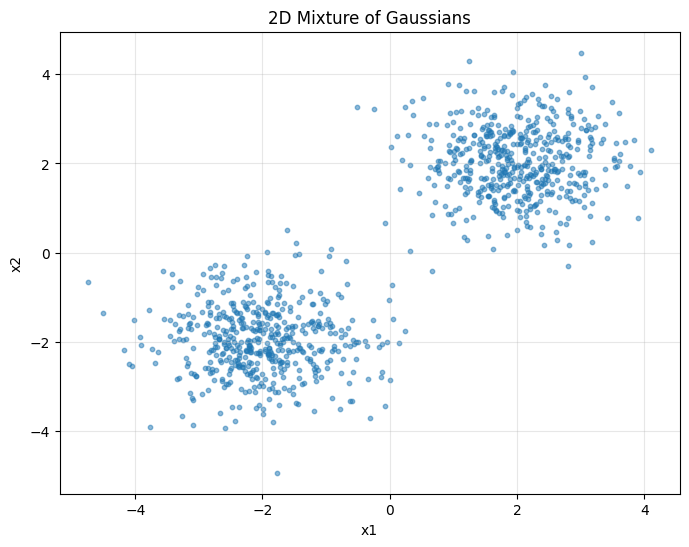

In [41]:

# Let's visualize score functions on a simple 2D distribution
# We'll use a mixture of Gaussians as our example

def create_2d_mixture(num_samples=1000, device='cpu'):
    """Create a 2D mixture of Gaussians dataset"""
    # Two Gaussian components
    mu1 = torch.tensor([2.0, 2.0])
    mu2 = torch.tensor([-2.0, -2.0])
    sigma = 0.8
    
    # Sample from both components
    n1 = num_samples // 2
    n2 = num_samples - n1
    
    samples1 = torch.randn(n1, 2) * sigma + mu1
    samples2 = torch.randn(n2, 2) * sigma + mu2
    
    data = torch.cat([samples1, samples2], dim=0)
    return data.to(device)

# Create and visualize the data
data_2d = create_2d_mixture(1000, device)
plt.figure(figsize=(8, 6))
plt.scatter(data_2d[:, 0].cpu().numpy(), data_2d[:, 1].cpu().numpy(), alpha=0.5, s=10)
plt.title("2D Mixture of Gaussians")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True, alpha=0.3)
plt.show()


## 1.2 Score Matching

To learn the score function, we use **denoising score matching**. The idea is:
1. Add noise to data: $\tilde{x} = x + \sigma \epsilon$ where $\epsilon \sim \mathcal{N}(0, I)$
2. Learn to predict the score of the noisy distribution: $s_\theta(\tilde{x}, \sigma) \approx \nabla_{\tilde{x}} \log p_\sigma(\tilde{x})$
3. The score matching objective is:
   $$\mathcal{L} = \mathbb{E}_{x \sim p_{data}, \epsilon \sim \mathcal{N}(0,I), \sigma} \left[ \| s_\theta(\tilde{x}, \sigma) + \frac{\epsilon}{\sigma} \|^2 \right]$$

Note: The true score of a Gaussian noise distribution is $-\frac{\epsilon}{\sigma}$,
so we're learning to predict this.

In [42]:

class ScoreNetwork2D(nn.Module):
    """Simple MLP for 2D score estimation"""
    
    def __init__(self, hidden_dim=128, num_layers=3):
        super().__init__()
        layers = []
        layers.append(nn.Linear(3, hidden_dim))  # 2D input + 1D noise level
        layers.append(nn.SiLU())
        
        for _ in range(num_layers - 2):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.SiLU())
        
        layers.append(nn.Linear(hidden_dim, 2))  # 2D output (score)
        self.net = nn.Sequential(*layers)
    
    def forward(self, x, sigma):
        """
        Args:
            x: (batch_size, 2) - 2D points
            sigma: (batch_size,) - noise levels
        Returns:
            score: (batch_size, 2) - score function
        """
        # Concatenate x and sigma
        sigma_expanded = sigma.unsqueeze(-1)  # (batch_size, 1)
        x_with_sigma = torch.cat([x, sigma_expanded], dim=-1)  # (batch_size, 3)
        
        return self.net(x_with_sigma)


Now let's implement the denoising score matching loss:

In [43]:

def score_matching_loss(model, data, sigma, device='cpu'):
    """
    Denoising score matching loss
    
    Args:
        model: Score network
        data: (batch_size, 2) - clean data points
        sigma: (batch_size,) - noise levels
        device: Device to use
    Returns:
        loss: Scalar loss value
    """
    # À compléter...  
    model = model.to(device)
    data = data.to(device)
    sigma = sigma.to(device)
    
    epsilon = torch.randn(data.shape).to(device)
    sigma_expanded = sigma.unsqueeze(-1).to(device)
    x_tilde = (data + epsilon*sigma_expanded).to(device)

    loss = torch.mean((model(x_tilde, sigma) + epsilon/sigma_expanded)**2)
    
    return loss

# Test the loss function
model_2d = ScoreNetwork2D().to(device)
test_data = torch.randn(32, 2).to(device)
test_sigma = torch.ones(32).to(device) * 0.5
loss = score_matching_loss(model_2d, test_data, test_sigma, device)
print(f"Test loss: {loss.item():.4f}")

Test loss: 3.8548



## 1.3 Training the Score Network

Let's train the score network on our 2D mixture of Gaussians:

In [46]:

# À compléter...  
def trainScoreBased2D(data, sigma, device='cpu'):

    model = ScoreNetwork2D().to(device)

    optim = torch.optim.Adam(model.parameters())
    losses = []

    data = data.to(device)
    sigma = sigma.to(device)
    
    for i in range(epochs):
        
        model(data, sigma)

        loss = score_matching_loss(model, data, sigma, device)
        losses.append(loss)

        optim.zero_grad()
        loss.backward()
        optim.step()

    print("Training completed!")

train_data = torch.randn(32, 2).to(device)
train_sigma = torch.ones(32).to(device) * 0.5
trainScoreBased2D(train_data, train_sigma, device)

Training completed!



## 1.4 Langevin Dynamics Sampling

Once we have a trained score network, we can sample using **Langevin dynamics**:
$$x_{t+1} = x_t + \frac{\epsilon}{2} \nabla_x \log p(x_t) + \sqrt{\epsilon} z$$

where $z \sim \mathcal{N}(0, I)$ and $\epsilon$ is the step size.

For better sampling, we use **annealed Langevin dynamics**:
- Start with high noise level (large $\sigma$)
- Gradually decrease noise level
- At each level, run multiple Langevin steps

In [47]:

def langevin_step(model, x, sigma, step_size, device='cpu'):
    """
    Single Langevin dynamics step
    
    Args:
        model: Score network
        x: (batch_size, 2) - current samples
        sigma: (batch_size,) - current noise levels
        step_size: Step size for Langevin dynamics
        device: Device to use
    Returns:
        x_new: (batch_size, 2) - updated samples
    """
    # Get score
    score = model(x, sigma)
    
    # Langevin step: x_new = x + (step_size/2) * score + sqrt(step_size) * noise
    noise = torch.randn_like(x)
    x_new = x + (step_size / 2) * score + math.sqrt(step_size) * noise
    
    return x_new

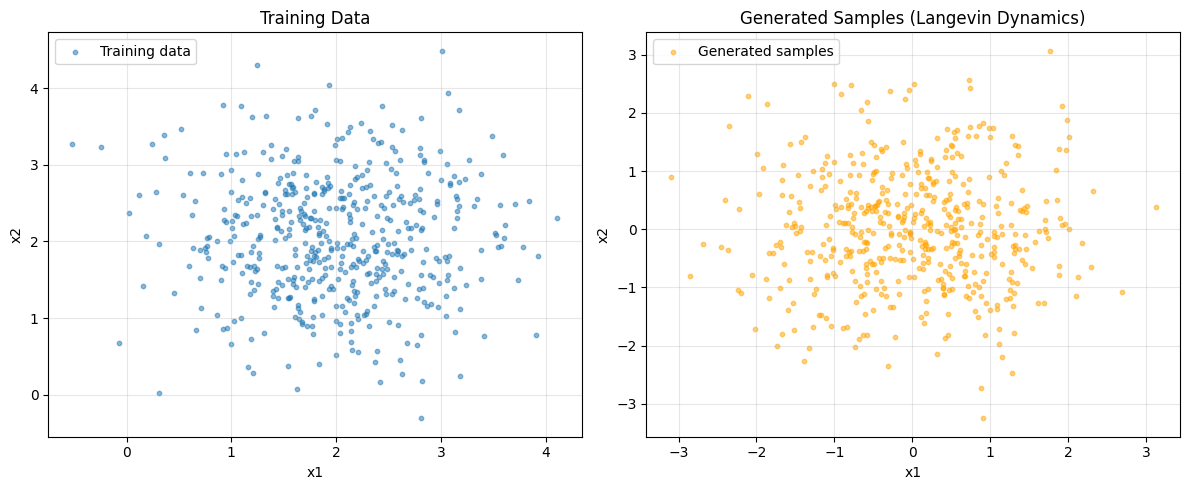

In [55]:

def annealed_langevin_sample(model, num_samples, sigma_levels, steps_per_level, step_size, device='cpu'):
    """
    Annealed Langevin dynamics sampling
    
    Args:
        model: Trained score network
        num_samples: Number of samples to generate
        sigma_levels: List of noise levels (from high to low)
        steps_per_level: Number of Langevin steps per noise level
        step_size: Step size for Langevin dynamics
        device: Device to use
    Returns:
        samples: (num_samples, 2) - generated samples
    """
    # À compléter...  

    # generate num_samples samples
    samples = torch.randn(num_samples, 2).to(device)
    
    # do steps_per_level steps for each sigma in sigma_levels
    for sigma in sigma_levels:
        sigma_batch = torch.full((num_samples,), sigma, device=device)
        
        for i in range(steps_per_level):
        
            samples = langevin_step(model, samples, sigma_batch, step_size, device)
    
    return samples


sigma_levels = torch.Tensor([1.0, 0.3, 0.1, 0.03, 0.01]).to(device)

# Test sampling
with torch.no_grad():
    model_2d.eval()
    samples = annealed_langevin_sample(
        model_2d,
        num_samples=500,
        sigma_levels=sigma_levels,  # From high to low
        steps_per_level=10,
        step_size=2e-5,
        device=device
    )

# Visualize generated samples
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(data_2d[:500, 0].cpu().numpy(), data_2d[:500, 1].cpu().numpy(), 
            alpha=0.5, s=10, label='Training data')
plt.title("Training Data")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(samples[:, 0].cpu().numpy(), samples[:, 1].cpu().numpy(), 
            alpha=0.5, s=10, label='Generated samples', color='orange')
plt.title("Generated Samples (Langevin Dynamics)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 1.5 Visualizing Score Fields

Let's visualize the learned score function to understand what it's doing:

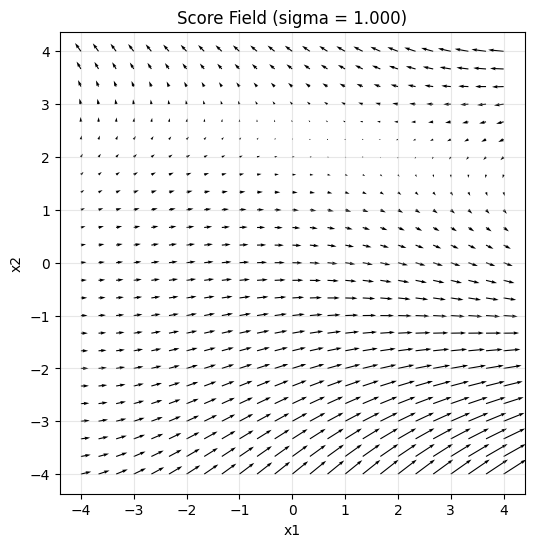

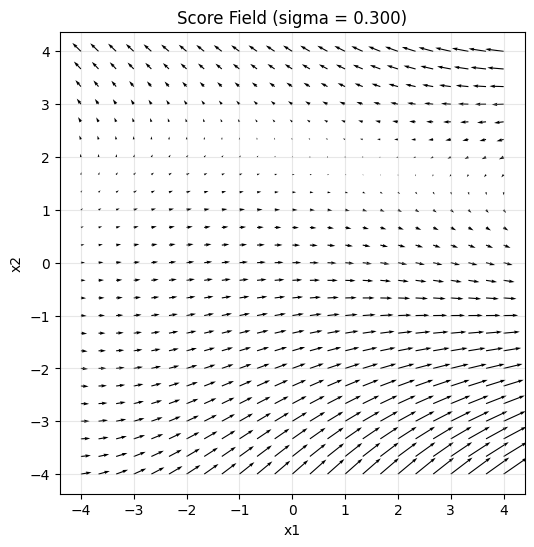

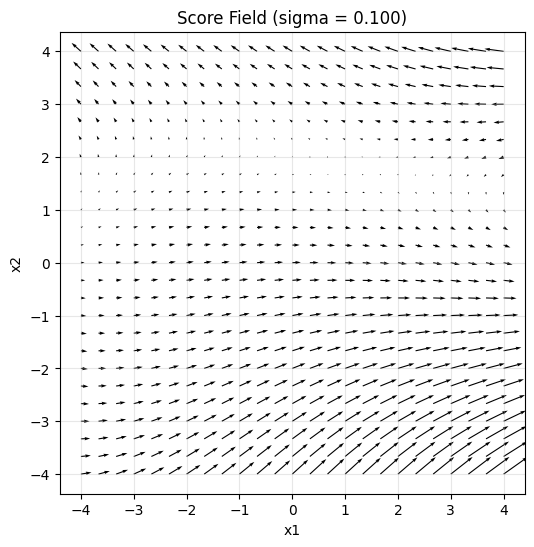

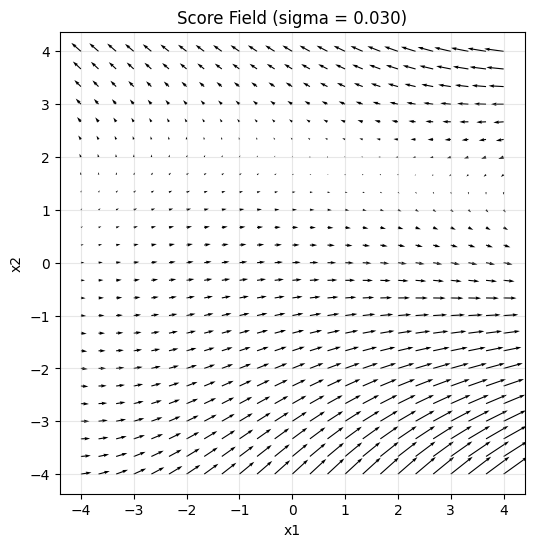

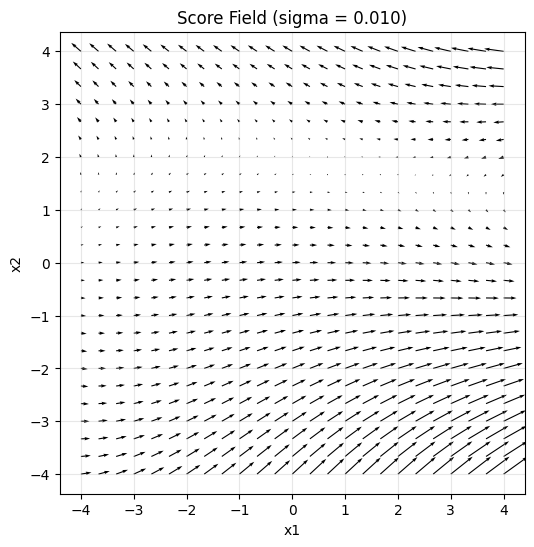

In [59]:

# À compléter...  
import numpy as np
import matplotlib.pyplot as plt

def visualize_score_field(model, sigma, xlim=(-4, 4), ylim=(-4, 4), grid_size=25, device='cpu'):

    model.eval()

    # create grid of points
    x = np.linspace(xlim[0], xlim[1], grid_size)
    y = np.linspace(ylim[0], ylim[1], grid_size)
    xx, yy = np.meshgrid(x, y)

    grid = np.stack([xx.ravel(), yy.ravel()], axis=1)
    grid = torch.tensor(grid, dtype=torch.float32).to(device)

    sigma_batch = torch.full((grid.shape[0],), sigma, device=device)

    with torch.no_grad():
        scores = model(grid, sigma_batch)

    scores = scores.cpu().numpy()

    # reshape 
    U = scores[:, 0].reshape(grid_size, grid_size)
    V = scores[:, 1].reshape(grid_size, grid_size)

    plt.figure(figsize=(6, 6))
    plt.quiver(xx, yy, U, V, angles='xy')
    plt.title(f"Score Field (sigma = {sigma:.3f})")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.grid(True, alpha=0.3)
    plt.axis("equal")
    plt.show()


for sigma in sigma_levels:
    visualize_score_field(
        model_2d,
        sigma,
        device=device
    )


# Part 2: Score-Based Models for Images and Connection to Diffusion

Now we'll apply score-based models to image generation (MNIST) and understand
the connection to diffusion models.


## 2.1 Loading MNIST Dataset

Image shape: torch.Size([28, 28])
Channels: 1


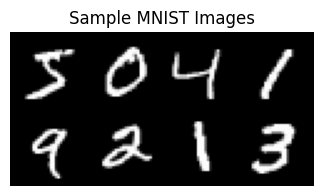

In [108]:

# Load MNIST dataset
transform = transforms.Compose([
    transforms.ToTensor()  # Converts to [0, 1] range and adds channel dimension
])

train_data = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Get image properties
sample_image = train_data[0][0]
image_channels = sample_image.shape[0]  # Should be 1 for grayscale MNIST
image_shape = sample_image.shape[1:]  # (28, 28)

print(f"Image shape: {image_shape}")
print(f"Channels: {image_channels}")

# Show some images
sample_images = torch.stack([train_data[i][0] for i in range(8)])
grid = make_grid(sample_images, nrow=4)
plt.figure(figsize=(8, 2))
plt.imshow(grid.permute(1, 2, 0).squeeze().cpu().numpy(), cmap='gray')
plt.axis('off')
plt.title("Sample MNIST Images")
plt.show()


## 2.2 U-Net Architecture for Score Estimation

For images, we need a more sophisticated architecture. We'll use a U-Net,
similar to what's used in diffusion models, but adapted for score estimation.

In [114]:

class SinusoidalPositionEmbeddings(nn.Module):
    """Positional embeddings for time/noise level"""
    
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
        assert dim % 2 == 0, "Positional embeddings should be multiples of 2"
    
    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

In [115]:

class Block(nn.Module):
    def __init__(self, dim, dim_out, groups=8):
        super().__init__()
        self.proj = nn.Conv2d(dim, dim_out, 3, padding=1)
        self.norm = nn.GroupNorm(groups, dim_out)
        self.act = nn.SiLU()
    
    def forward(self, x, scale_shift=None):
        x = self.proj(x)
        x = self.norm(x)
        if scale_shift is not None:
            scale, shift = scale_shift
            x = x * (scale + 1) + shift
        x = self.act(x)
        return x

class ResnetBlock(nn.Module):
    def __init__(self, dim, dim_out, *, time_emb_dim=None, groups=8):
        super().__init__()
        self.mlp = (
            nn.Sequential(nn.SiLU(), nn.Linear(time_emb_dim, dim_out))
            if time_emb_dim
            else None
        )
        self.block1 = Block(dim, dim_out, groups=groups)
        self.block2 = Block(dim_out, dim_out, groups=groups)
        self.res_conv = nn.Conv2d(dim, dim_out, 1) if dim != dim_out else nn.Identity()
    
    def forward(self, x, time_emb=None):
        h = self.block1(x)
        if self.mlp is not None and time_emb is not None:
            time_emb = self.mlp(time_emb)
            h = h + time_emb.unsqueeze(-1).unsqueeze(-1)
        h = self.block2(h)
        return h + self.res_conv(x)

def Upsample(dim):
    return nn.ConvTranspose2d(dim, dim, kernel_size=4, stride=2, padding=1)

def Downsample(dim):
    return nn.Conv2d(dim, dim, kernel_size=4, stride=2, padding=1)

class Unet(nn.Module):
    def __init__(
        self,
        dim,
        *,
        init_dim=None,
        out_dim=None,
        dim_mults=(1, 2, 4),
        channels=1,
        time_dim=None,
        resnet_block_groups=4,
    ):
        super().__init__()
        self.channels = channels
        self.time_dim = time_dim
        
        init_dim = init_dim or (dim // 3 * 2)
        # Ensure init_dim is divisible by resnet_block_groups
        init_dim = ((init_dim + resnet_block_groups - 1) // resnet_block_groups) * resnet_block_groups
        self.init_conv = nn.Conv2d(channels, init_dim, 7, padding=3)
        
        dims = [init_dim, *(dim * m for m in dim_mults)]
        # Ensure all dims are divisible by resnet_block_groups
        dims = [((d + resnet_block_groups - 1) // resnet_block_groups) * resnet_block_groups for d in dims]
        in_out = list(zip(dims[:-1], dims[1:]))
        
        resnet_block = partial(ResnetBlock, groups=resnet_block_groups)
        
        self.downs = nn.ModuleList([])
        self.ups = nn.ModuleList([])
        num_resolutions = len(in_out)
        
        for ind, (dim_in, dim_out) in enumerate(in_out):
            is_last = ind >= (num_resolutions - 1)
            self.downs.append(
                nn.ModuleList(
                    [
                        resnet_block(dim_in, dim_out, time_emb_dim=time_dim),
                        resnet_block(dim_out, dim_out, time_emb_dim=time_dim),
                        Downsample(dim_out) if not is_last else nn.Identity(),
                    ]
                )
            )
        
        mid_dim = dims[-1]
        self.mid_block1 = ResnetBlock(mid_dim, mid_dim, time_emb_dim=time_dim, groups=resnet_block_groups)
        self.mid_block2 = ResnetBlock(mid_dim, mid_dim, time_emb_dim=time_dim, groups=resnet_block_groups)
        
        # Store the actual channel dimensions for skip connections
        # In downsample: we save feature maps with dim_out channels
        # In upsample: we concatenate x (from previous upsample with dim_out channels) with h (saved dim_out channels)
        # So the actual concat_dim should be dim_out + dim_out, not dim_out + dim_in
        for ind, (dim_in, dim_out) in enumerate(reversed(in_out)):
            is_last = ind >= (num_resolutions - 1)
            # The skip connection h has dim_out channels (from downsample)
            # x coming from previous upsample also has dim_out channels
            # So we concatenate dim_out + dim_out
            concat_dim = dim_out + dim_out
            # Ensure concat_dim is divisible by resnet_block_groups
            concat_dim = ((concat_dim + resnet_block_groups - 1) // resnet_block_groups) * resnet_block_groups
            self.ups.append(
                nn.ModuleList(
                    [
                        resnet_block(concat_dim, dim_in, time_emb_dim=time_dim),
                        resnet_block(dim_in, dim_in, time_emb_dim=time_dim),
                        Upsample(dim_in) if not is_last else nn.Identity(),
                    ]
                )
            )
        
        out_dim = out_dim or channels
        # Final conv receives concatenated x (dims[0] channels) + r (init_dim channels)
        # Since init_dim == dims[0] after rounding, we get 2 * dims[0] channels
        final_conv_input_dim = dims[0] + init_dim  # This equals 2 * dims[0] since init_dim == dims[0]
        # Ensure it's divisible by resnet_block_groups
        final_conv_input_dim = ((final_conv_input_dim + resnet_block_groups - 1) // resnet_block_groups) * resnet_block_groups
        self.final_conv = nn.Sequential(
            Block(final_conv_input_dim, dims[0], groups=resnet_block_groups), nn.Conv2d(dims[0], out_dim, 1)
        )
    
    def forward(self, x, time):
        x = self.init_conv(x)
        r = x.clone()

        h = []
        for idx, (block1, block2, downsample) in enumerate(self.downs):
            x = block1(x, time)
            x = block2(x, time)
            h.append(x)
            x = downsample(x)

        x = self.mid_block1(x, time)
        x = self.mid_block2(x, time)

        for idx, (block1, block2, upsample) in enumerate(self.ups):
            h_popped = h.pop()
            x = torch.cat((x, h_popped), dim=1)
            x = block1(x, time)
            x = block2(x, time)
            x = upsample(x)
        
        x = torch.cat((x, r), dim=1)
        return self.final_conv(x)

In [116]:

class ScoreNetwork(nn.Module):
    """U-Net based score network for images"""
    
    def __init__(self, dim, channels=1, time_dim=32):
        super().__init__()
        self.image_size = dim
        self.channels = channels
        self.time_dim = time_dim
        
        # À compléter...  
        self.time_embedding = SinusoidalPositionEmbeddings(time_dim)

        self.unet = Unet(dim=dim, channels=channels, time_dim=time_dim)

    
    def forward(self, x, sigma):
        """
        Args:
            x: (batch_size, channels, H, W) - noisy images
            sigma: (batch_size,) - noise levels
        Returns:
            score: (batch_size, channels, H, W) - score function
        """
        # À compléter...  
        t_emb = self.time_embedding(sigma)

        return self.unet(x, t_emb)


# Initialize model
model = ScoreNetwork(image_shape[0], image_channels, time_dim=32).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 1,431,077



## 2.3 Training the Score Network

We'll train using denoising score matching on noisy images at multiple noise levels.

In [125]:

def score_matching_loss_images(model, images, sigma, device='cpu'):
    """
    Denoising score matching loss for images
    
    Args:
        model: Score network
        images: (batch_size, C, H, W) - clean images
        sigma: (batch_size,) - noise levels
        device: Device to use
    Returns:
        loss: Scalar loss value
    """
    batch_size = images.shape[0]
    
    # À compléter...  
    images = images.to(device)
    sigma_batch = sigma.view(batch_size, 1, 1, 1).to(device)
    e = torch.randn(images.shape, device = device)
    
    x_tilde = images + sigma_batch * e

    score_pred = model(x_tilde, sigma)

    loss = ((score_pred + e / sigma_batch) ** 2) * (sigma_batch ** 2)
    loss = loss.mean()
    
    return loss


Now let's train the model:

In [126]:

# À compléter...  
lr = 1e-4
batch_size = 128
epochs = 50
sigma_min = 0.05
sigma_max = 2.0

model.to(device)
device = next(model.parameters()).device

loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

model.train()

for epoch in range(epochs):
    losses = 0.0

    for images, _ in loader:
        B = images.shape[0]
        images = images.to(device)

        u = torch.rand(B, device=device)
        sigmas = sigma_min * (sigma_max / sigma_min) ** u

        loss = score_matching_loss_images(model, images, sigmas, device)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses += loss.item()

    avg_loss = losses / len(loader)
    print(f"Epoch {epoch+1}: loss = {avg_loss:.4f}")

print("Training completed!")

Epoch 1: loss = 0.0557
Epoch 2: loss = 0.0528
Epoch 3: loss = 0.0522
Epoch 4: loss = 0.0521
Epoch 5: loss = 0.0513
Epoch 6: loss = 0.0509
Epoch 7: loss = 0.0507
Epoch 8: loss = 0.0505
Epoch 9: loss = 0.0502
Epoch 10: loss = 0.0501
Epoch 11: loss = 0.0500
Epoch 12: loss = 0.0498
Epoch 13: loss = 0.0497
Epoch 14: loss = 0.0497
Epoch 15: loss = 0.0494
Epoch 16: loss = 0.0494
Epoch 17: loss = 0.0492
Epoch 18: loss = 0.0490
Epoch 19: loss = 0.0489
Epoch 20: loss = 0.0489
Epoch 21: loss = 0.0488
Epoch 22: loss = 0.0488
Epoch 23: loss = 0.0486
Epoch 24: loss = 0.0484
Epoch 25: loss = 0.0483
Epoch 26: loss = 0.0485
Epoch 27: loss = 0.0482
Epoch 28: loss = 0.0483
Epoch 29: loss = 0.0479
Epoch 30: loss = 0.0481
Epoch 31: loss = 0.0478
Epoch 32: loss = 0.0477
Epoch 33: loss = 0.0480
Epoch 34: loss = 0.0480
Epoch 35: loss = 0.0477
Epoch 36: loss = 0.0479
Epoch 37: loss = 0.0478
Epoch 38: loss = 0.0476
Epoch 39: loss = 0.0477
Epoch 40: loss = 0.0474
Epoch 41: loss = 0.0471
Epoch 42: loss = 0.0473
E


## 2.4 Mathematical Connection to Diffusion Models

A key insight is that **score-based models and diffusion models are mathematically equivalent**!

In diffusion models, we learn to predict noise: $\epsilon_\theta(x_t, t)$

In score-based models, we learn the score: $s_\theta(x, \sigma) = \nabla_x \log p_\sigma(x)$

The connection is:
$$\epsilon_\theta(x_t, t) = -\sigma_t \cdot s_\theta(x_t, \sigma_t)$$

This means: **predicting noise is equivalent to learning the score function** (up to a scaling factor)!

In [127]:

# Let's verify this connection by showing the relationship
# If we have a noisy image x_tilde = x + sigma * epsilon,
# then the score is: score = -epsilon / sigma
# And if we predict noise: noise_pred = epsilon
# Then: noise_pred = -sigma * score

print("Mathematical Connection:")
print("=" * 50)
print("In diffusion models: predict noise ε_θ(x_t, t)")
print("In score-based models: learn score s_θ(x, σ) = ∇_x log p_σ(x)")
print()
print("Connection: ε_θ(x_t, t) = -σ_t · s_θ(x_t, σ_t)")
print()
print("This means both approaches learn the same underlying information!")
print("=" * 50)

Mathematical Connection:
In diffusion models: predict noise ε_θ(x_t, t)
In score-based models: learn score s_θ(x, σ) = ∇_x log p_σ(x)

Connection: ε_θ(x_t, t) = -σ_t · s_θ(x_t, σ_t)

This means both approaches learn the same underlying information!



## 2.5 Image Generation with Annealed Langevin Dynamics

Now let's generate images using the trained score network:

In [128]:

def langevin_step_images(model, x, sigma, step_size, device='cpu'):
    """
    Single Langevin dynamics step for images
    
    Args:
        model: Score network
        x: (batch_size, C, H, W) - current images
        sigma: (batch_size,) - current noise levels
        step_size: Step size for Langevin dynamics
        device: Device to use
    Returns:
        x_new: (batch_size, C, H, W) - updated images
    """
    # Get score
    score = model(x, sigma)
    
    # Langevin step
    noise = torch.randn_like(x)
    x_new = x + (step_size / 2) * score + math.sqrt(step_size) * noise
    
    return x_new

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.27267918..1.1916245].


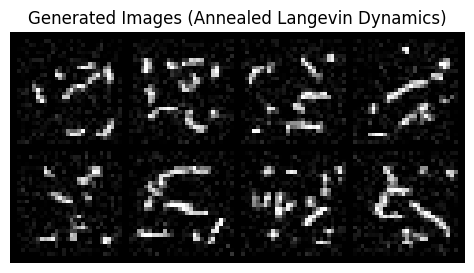

In [136]:

def annealed_langevin_sample_images(model, num_samples, sigma_levels, steps_per_level, step_size, image_shape, channels, device='cpu'):
    """
    Annealed Langevin dynamics sampling for images
    
    Args:
        model: Trained score network
        num_samples: Number of samples to generate
        sigma_levels: List of noise levels (from high to low)
        steps_per_level: Number of Langevin steps per noise level
        step_size: Step size for Langevin dynamics
        image_shape: (H, W) tuple
        channels: Number of channels
        device: Device to use
    Returns:
        samples: (num_samples, C, H, W) - generated images
    """
    # À compléter...  
    
    # generate num_samples samples
    shape = (num_samples, channels, image_shape[0], image_shape[1])
    samples = torch.randn(shape).to(device)
    
    # do steps_per_level steps for each sigma in sigma_levels
    for sigma in sigma_levels:
        sigma_batch = torch.full((num_samples,), sigma, device=device)
        
        for i in range(steps_per_level):
        
            samples = langevin_step_images(model, samples, sigma_batch, step_size, device)
    
    return samples


# Generate samples
with torch.no_grad():
    model.eval()
    generated_samples = annealed_langevin_sample_images(
        model,
        num_samples=8,
        sigma_levels=sigma_levels,  # From high to low
        steps_per_level=200,
        step_size=1e-3,
        image_shape=image_shape,
        channels=image_channels,
        device=device
    )

# Visualize generated images
grid = make_grid(generated_samples, nrow=4)
plt.figure(figsize=(10, 3))
plt.imshow(grid.permute(1, 2, 0).squeeze().cpu().numpy(), cmap='gray')
plt.axis('off')
plt.title("Generated Images (Annealed Langevin Dynamics)")
plt.show()


## 2.6 Conceptual Comparison with Diffusion Models

**Denoising Perspective (Diffusion Models)**:
- Learn to predict noise: $\epsilon_\theta(x_t, t)$
- Sampling: Discrete reverse steps, removing predicted noise
- Focus: Forward/reverse diffusion process

**Score-Based Perspective (This Lab)**:
- Learn gradient of log-probability: $s_\theta(x, \sigma) = \nabla_x \log p_\sigma(x)$
- Sampling: Langevin dynamics, following gradients
- Focus: Score function and gradient-based sampling

**Key Insight**: Both learn the same information! The mathematical equivalence
means we can use either perspective, and they're just different ways of thinking
about the same underlying model.


# Part 3: Advanced Sampling Methods (Optional - Home Learning)

This part explores advanced sampling methods: SDE and ODE formulations.
It's optional and can be completed at home for deeper understanding.


## 3.1 SDE Formulation

Score-based models can be formulated as **Stochastic Differential Equations (SDEs)**.

**Forward SDE** (adding noise):
$$dx = f(x, t)dt + g(t)dw$$

**Reverse SDE** (generation):
$$dx = [f(x, t) - g(t)^2 \nabla_x \log p_t(x)]dt + g(t)d\bar{w}$$

where $d\bar{w}$ is Brownian motion running backwards in time.

In [ ]:

class VP_SDE:
    """Variance Preserving SDE (connects to diffusion models)"""
    
    def __init__(self, beta_min=0.1, beta_max=20.0):
        self.beta_min = beta_min
        self.beta_max = beta_max
    
    def beta(self, t):
        """Beta schedule"""
        # Convert to scalar if tensor
        if isinstance(t, torch.Tensor):
            t_val = t.item() if t.numel() == 1 else float(t)
        else:
            t_val = float(t)
        return self.beta_min + t_val * (self.beta_max - self.beta_min)
    
    def f(self, x, t):
        """Drift coefficient: f(x, t) = -0.5 * beta(t) * x"""
        beta_t = self.beta(t)
        return -0.5 * beta_t * x
    
    def g(self, t):
        """Diffusion coefficient: g(t) = sqrt(beta(t))"""
        beta_t = self.beta(t)
        return math.sqrt(beta_t)

class VE_SDE:
    """Variance Exploding SDE"""
    
    def __init__(self, sigma_min=0.01, sigma_max=50.0):
        self.sigma_min = sigma_min
        self.sigma_max = sigma_max
    
    def sigma(self, t):
        """Sigma schedule"""
        # Convert to scalar if tensor
        if isinstance(t, torch.Tensor):
            t_val = t.item() if t.numel() == 1 else float(t)
        else:
            t_val = float(t)
        return self.sigma_min * (self.sigma_max / self.sigma_min) ** t_val
    
    def f(self, x, t):
        """Drift coefficient: f(x, t) = 0 (no drift)"""
        return torch.zeros_like(x)
    
    def g(self, t):
        """Diffusion coefficient: g(t) = sigma(t) * sqrt(2 * log(sigma_max/sigma_min))"""
        sigma_t = self.sigma(t)
        return sigma_t * math.sqrt(2 * math.log(self.sigma_max / self.sigma_min))


## 3.2 Euler-Maruyama SDE Solver

The Euler-Maruyama method is a simple numerical solver for SDEs:
$$x_{t+\Delta t} = x_t + f(x_t, t)\Delta t + g(t)\sqrt{\Delta t} \cdot z$$

where $z \sim \mathcal{N}(0, I)$.

In [ ]:

def euler_maruyama_solver(model, sde, x_init, num_steps, device='cpu'):
    """
    Euler-Maruyama solver for reverse SDE
    
    Args:
        model: Score network (learns ∇_x log p_t(x))
        sde: SDE object (VP_SDE or VE_SDE)
        x_init: Initial samples (high noise)
        num_steps: Number of integration steps
        device: Device to use
    Returns:
        samples: Generated samples
    """
    # À compléter...  
    assert False, 'Code non implémenté'
    
    return x


## 3.3 Probability Flow ODE

The **Probability Flow ODE** is a deterministic version of the reverse SDE:
$$dx = [f(x, t) - \frac{1}{2}g(t)^2 \nabla_x \log p_t(x)]dt$$

This gives deterministic sampling (no randomness), similar to DDIM in diffusion models.

In [ ]:

def probability_flow_ode(model, sde, x_init, num_steps, device='cpu'):
    """
    Probability Flow ODE (deterministic sampling)
    
    Args:
        model: Score network
        sde: SDE object
        x_init: Initial samples
        num_steps: Number of integration steps
        device: Device to use
    Returns:
        samples: Generated samples
    """
    # À compléter...  
    assert False, 'Code non implémenté'
    
    return x_final


## 3.4 Comparison of Sampling Methods

Let's compare the different sampling methods we've implemented:

In [ ]:

# À compléter...  
assert False, 'Code non implémenté'
